In [1]:
import math

import dnois
from dnois.optics import rt
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_grad_enabled(False)

In [3]:
dnois.mt.register(dnois.mt.Sellmeier1(
    'SK2',
    [1.28189012, 0.257738258, 0.968186040],
    [7.27191640e-3, 2.42823527e-2, 1.10377773e2],
    0.31, 2.325
), exist_ok=True)
dnois.mt.register(dnois.mt.Sellmeier1(
    'SK16',
    [1.34317774, 2.41144399e-1, 9.943179690E-01],
    [7.04687339e-3, 2.29005000e-2, 9.27508526e1],
    0.31, 2.5
), exist_ok=True)
dnois.mt.register(dnois.mt.Sellmeier1(
    'F5',
    [1.31044630, 1.96034260e-1, 9.6612977e-1],
    [9.58633048e-3, 4.57627627e-2, 1.15011883e2],
    0.32, 2.5
), exist_ok=True)

In [4]:
slist = rt.CoaxialSurfaceList.load_json('double-gauss.json')
sensor = dnois.sensor.SimpleSensor(512, 5e-6, noise_std=1e-2)
optics = rt.CoaxialRayTracing(
    slist,
    0.1,  # nominal_focal_length
    sensor,
    sampler=slist[0].aperture.sampler('unipolar', 64, 36),
    wl=[dnois.fline('F'), dnois.fline('d', 'He'), dnois.fline('C')],
    depth=float('inf'),
)

camera = dnois.Camera(optics, sensor)
camera.double()
camera.to(device=device)

Camera(
  (optics): CoaxialRayTracing(
    (surfaces): CoaxialSurfaceList(
      (0): Spherical(
        material=SK2, reflective=False,
        roc=0.0541532
        (aperture): CircularAperture(radius=0.0293392)
        (context): CoaxialContext(distance=0.00874666)
      )
      (1): Spherical(
        material=vacuum, reflective=False,
        roc=0.152522
        (aperture): CircularAperture(radius=0.0282666)
        (context): CoaxialContext(distance=0.0005)
      )
      (2): Spherical(
        material=SK16, reflective=False,
        roc=0.0359506
        (aperture): CircularAperture(radius=0.0243546)
        (context): CoaxialContext(distance=0.014)
      )
      (3): Spherical(
        material=F5, reflective=False,
        roc=inf
        (aperture): CircularAperture(radius=0.0213582)
        (context): CoaxialContext(distance=0.00377697)
      )
      (4): Spherical(
        material=vacuum, reflective=False,
        roc=0.0222699
        (aperture): CircularAperture(radius

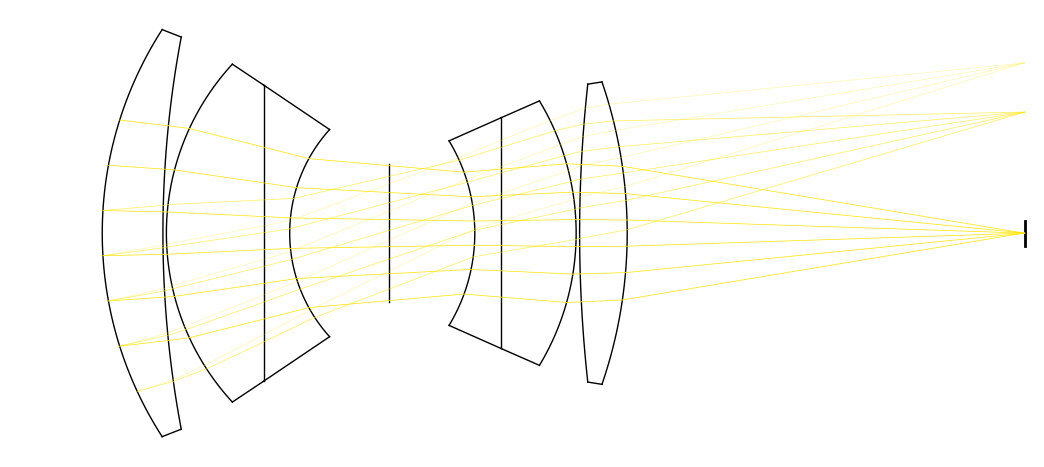

In [5]:
_ = optics.show_cross_section(fov=[0., math.radians(10.), math.radians(14.)], wl=588e-9, spp=10)

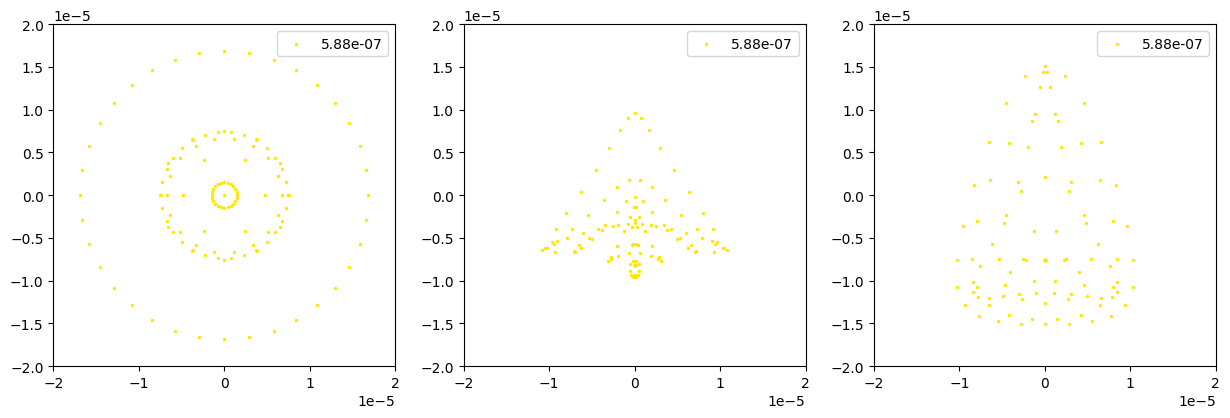

In [6]:
points = optics.fovd2obj([
    (0., 0.),
    (0., 10.),
    (0., 14.),
], float('inf'), True)
_ = optics.show_spot_diagram(points, 588e-9, entr_d=33.341e-3, entr_z=58.939e-3, width=2e-5)

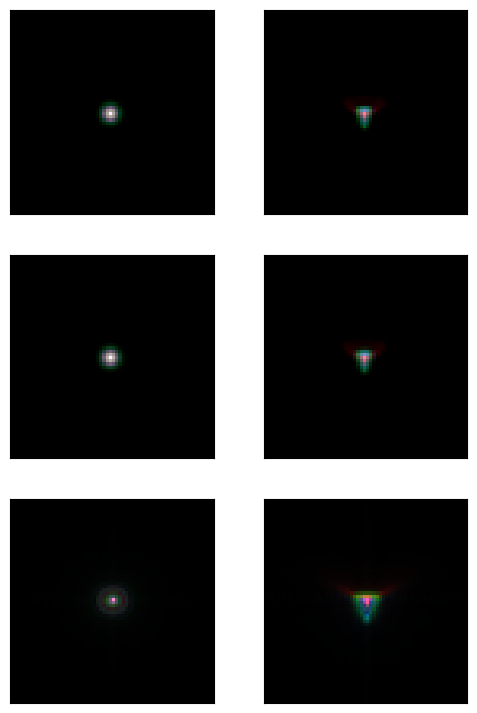

In [7]:
obj = optics.fovd2obj(torch.tensor([(0., 0.), (0., 14.)]).deg2rad().to(device), float('inf'))

psf_inc_rect = optics.psf(obj, psf_type='inc_rect', psf_center='mean')
psf_inc_gaussian = optics.psf(obj, psf_type='inc_gaussian', psf_center='mean')
# psf_coh_huygens = optics.psf(obj, psf_type='coh_huygens', psf_center='mean', samples=256)
# psf_coh_kirchoff = optics.psf(obj, psf_type='coh_kirchoff', psf_center='mean', samples=256)
psf_coh_fraunhofer = optics.psf(obj, psf_type='coh_fraunhofer', psf_center='chief', samples=512)

psfs = [
    psf_inc_rect,
    psf_inc_gaussian,
    # psf_coh_huygens,
    # psf_coh_kirchoff,
    psf_coh_fraunhofer,
]

fig, axs = plt.subplots(len(psfs), obj.size(0), figsize=(obj.size(0) * 3, len(psfs) * 3), squeeze=False)
for i, ax_row in enumerate(axs):
    for j, ax in enumerate(ax_row):
        psf_show = psfs[i][j]
        psf_show = psf_show / psf_show.sum((-2, -1), True)
        psf_show = psf_show / psf_show.max()
        psf_show = psf_show ** 0.5
        ax.imshow(dnois.utils.t4plot(psf_show.permute(1, 2, 0)))
        ax.set_xticks([])
        ax.set_yticks([])

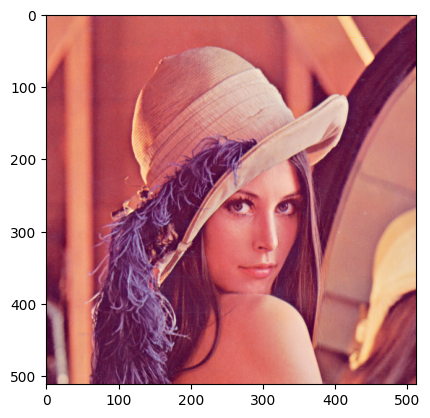

In [8]:
img_path = '../assets/LenaRGB.bmp'
img = Image.open(img_path)
img = torch.from_numpy(np.array(img)) / 255.
img = img.permute(2, 0, 1)
img = img.to(device=device)
scene = dnois.scene.ImageScene(img, batched=False).batch()

plt.imshow(img.permute(1, 2, 0).clamp(0, 1).cpu())

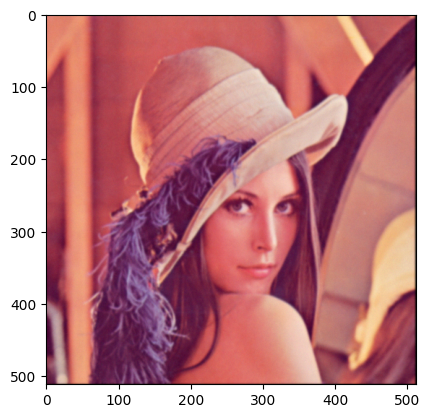

In [9]:
captured = camera(scene)
plt.imshow(captured.squeeze(0).permute(1, 2, 0).clamp(0, 1).cpu())